# Traffic Forecasting: Data Preprocessing & Complete Pipeline
**Comparing Traditional Models vs Graph Neural Networks on METR-LA & PEMS-BAY**

This notebook covers:
1. Data Loading & Exploration
2. Missing Value Handling
3. Graph Construction (Adjacency Matrix)
4. Train/Val/Test Split & Normalization
5. Model Training (ARIMA, RF, LSTM, STGCN, DCRNN)
6. Evaluation & Comparison
7. Visualization

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src import config
from src.config import set_seed, get_device

set_seed(42)
device = get_device()
print(f"PyTorch: {torch.__version__}")

Using GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.2 GB
PyTorch: 2.12.0+cu130


## 2. Data Loading & Exploration

In [2]:
# Load METR-LA
df_la = pd.read_csv(config.METR_LA_PATH, index_col=0, parse_dates=True)
print("=== METR-LA ===")
print(f"Shape: {df_la.shape} (timesteps × sensors)")
print(f"Time range: {df_la.index[0]} to {df_la.index[-1]}")
print(f"Interval: {(df_la.index[1] - df_la.index[0])}")
print(f"\nFirst 5 rows:")
df_la.head()

=== METR-LA ===
Shape: (34272, 207) (timesteps × sensors)
Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Interval: 0 days 00:05:00

First 5 rows:


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [3]:
# Load PEMS-BAY
df_bay = pd.read_csv(config.PEMS_BAY_PATH, index_col=0, parse_dates=True)
print("=== PEMS-BAY ===")
print(f"Shape: {df_bay.shape}")
print(f"Time range: {df_bay.index[0]} to {df_bay.index[-1]}")
df_bay.head()

=== PEMS-BAY ===
Shape: (52116, 325)
Time range: 2017-01-01 00:00:00 to 2017-06-30 23:55:00


,400001,400017,400030,400040,400045,400052,400057,400059,400065,400069,...,409525,409526,409528,409529,413026,413845,413877,413878,414284,414694
2017-01-01 00:00:00,71.4,67.8,70.5,67.4,68.8,66.6,66.8,68.0,66.8,69.0,...,68.8,67.9,68.8,68.0,69.2,68.9,70.4,68.8,71.1,68.0
2017-01-01 00:05:00,71.6,67.5,70.6,67.5,68.7,66.6,66.8,67.8,66.5,68.2,...,68.4,67.3,68.4,67.6,70.4,68.8,70.1,68.4,70.8,67.4
2017-01-01 00:10:00,71.6,67.6,70.2,67.4,68.7,66.1,66.8,67.8,66.2,67.8,...,68.4,67.4,68.4,67.5,70.2,68.3,69.8,68.4,70.5,67.9
2017-01-01 00:15:00,71.1,67.5,70.3,68.0,68.5,66.7,66.6,67.7,65.9,67.8,...,68.5,67.5,68.5,67.5,70.4,68.7,70.2,68.4,70.8,67.6
2017-01-01 00:20:00,71.7,67.8,70.2,68.1,68.4,66.9,66.1,67.7,66.1,67.8,...,68.5,67.7,68.5,67.4,69.6,69.1,70.0,68.4,71.0,67.9


In [4]:
# Basic statistics
print("=== METR-LA Statistics ===")
print(f"Missing (NaN): {df_la.isna().sum().sum()} ({df_la.isna().mean().mean():.2%})")
print(f"Zero values:   {(df_la == 0).sum().sum()} ({(df_la == 0).mean().mean():.2%})")
print(f"Min speed:     {df_la.min().min():.2f} mph")
print(f"Max speed:     {df_la.max().max():.2f} mph")
print(f"Mean speed:    {df_la.mean().mean():.2f} mph")
print(f"Std speed:     {df_la.std().mean():.2f} mph")

print(f"\n=== PEMS-BAY Statistics ===")
print(f"Missing (NaN): {df_bay.isna().sum().sum()} ({df_bay.isna().mean().mean():.2%})")
print(f"Zero values:   {(df_bay == 0).sum().sum()} ({(df_bay == 0).mean().mean():.2%})")
print(f"Min speed:     {df_bay.min().min():.2f} mph")
print(f"Max speed:     {df_bay.max().max():.2f} mph")
print(f"Mean speed:    {df_bay.mean().mean():.2f} mph")

=== METR-LA Statistics ===
Missing (NaN): 0 (0.00%)
Zero values:   575302 (8.11%)
Min speed:     0.00 mph
Max speed:     70.00 mph
Mean speed:    53.72 mph
Std speed:     19.19 mph

=== PEMS-BAY Statistics ===
Missing (NaN): 0 (0.00%)
Zero values:   521 (0.00%)
Min speed:     0.00 mph
Max speed:     85.10 mph
Mean speed:    62.62 mph


## 3. Data Visualization — Raw Data

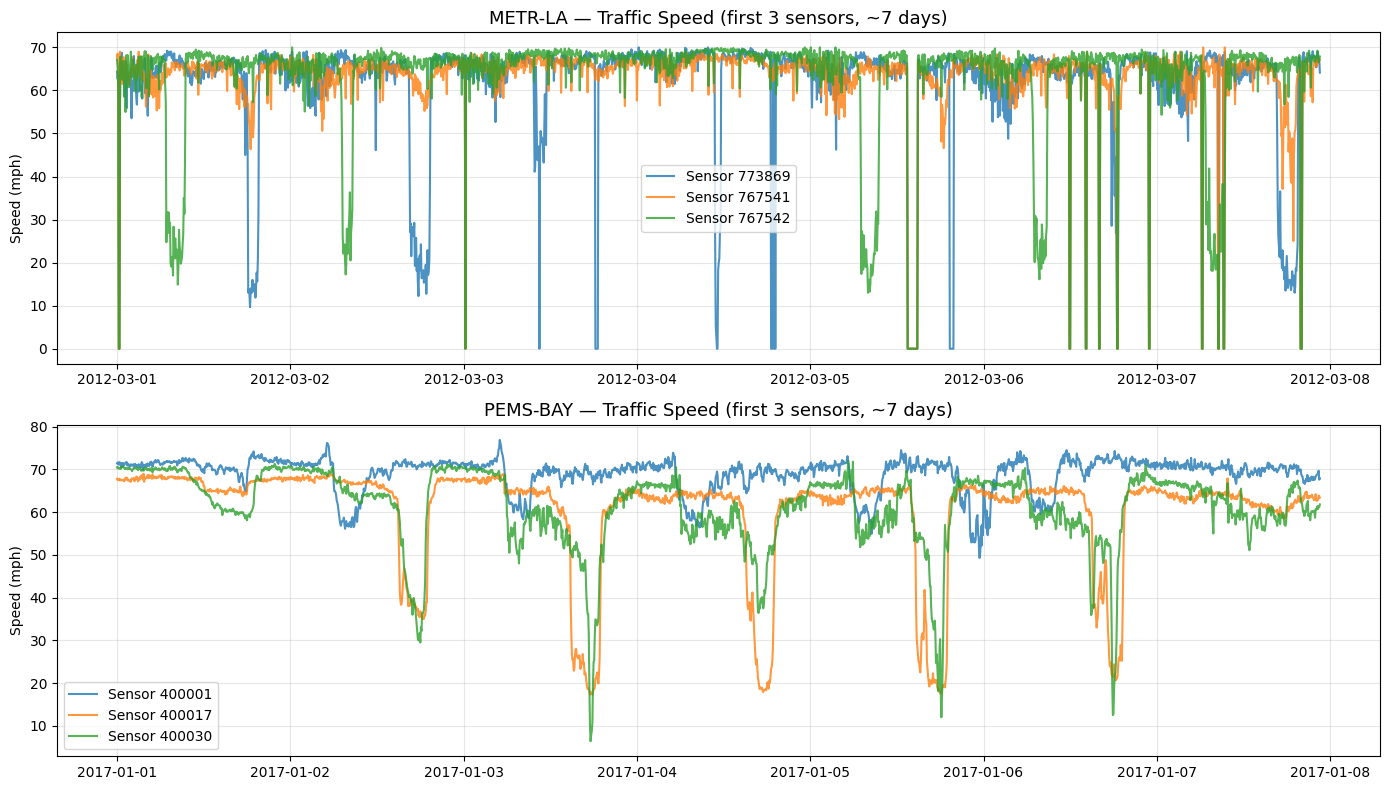

In [5]:
# Plot speed over time for sample sensors
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# METR-LA: first 3 sensors, first 2000 timesteps
for i, col in enumerate(df_la.columns[:3]):
    axes[0].plot(df_la.index[:2000], df_la[col].iloc[:2000], label=f'Sensor {col}', alpha=0.8)
axes[0].set_title('METR-LA — Traffic Speed (first 3 sensors, ~7 days)', fontsize=13)
axes[0].set_ylabel('Speed (mph)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PEMS-BAY: first 3 sensors, first 2000 timesteps
for i, col in enumerate(df_bay.columns[:3]):
    axes[1].plot(df_bay.index[:2000], df_bay[col].iloc[:2000], label=f'Sensor {col}', alpha=0.8)
axes[1].set_title('PEMS-BAY — Traffic Speed (first 3 sensors, ~7 days)', fontsize=13)
axes[1].set_ylabel('Speed (mph)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/raw_data_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

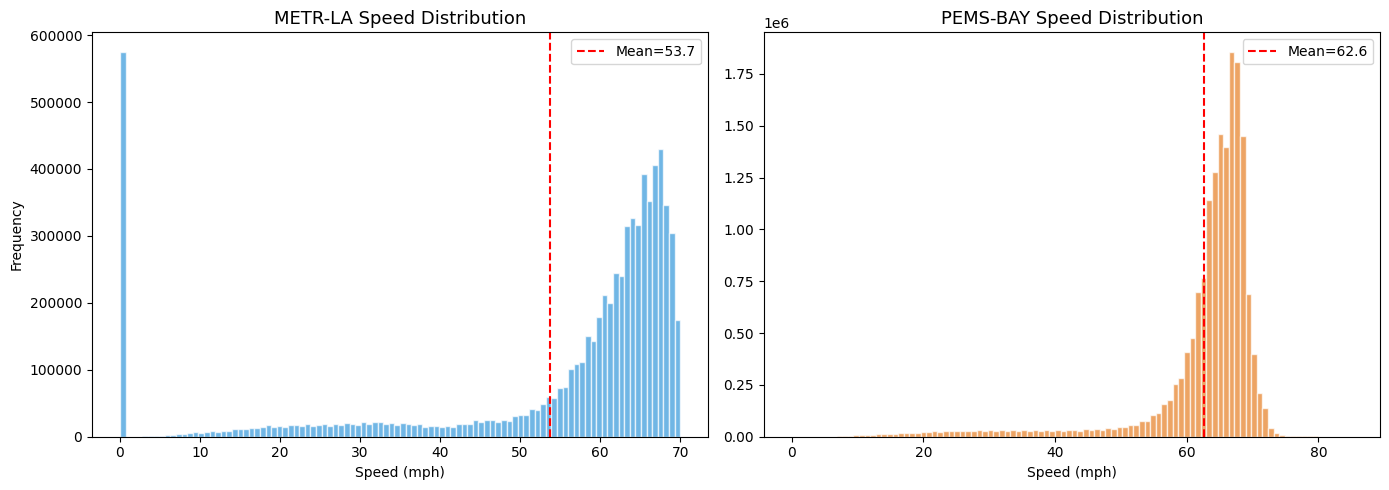

In [6]:
# Distribution of speeds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_la.values.flatten(), bins=100, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].set_title('METR-LA Speed Distribution', fontsize=13)
axes[0].set_xlabel('Speed (mph)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_la.values.mean(), color='red', linestyle='--', label=f'Mean={df_la.values.mean():.1f}')
axes[0].legend()

axes[1].hist(df_bay.values.flatten(), bins=100, color='#e67e22', alpha=0.7, edgecolor='white')
axes[1].set_title('PEMS-BAY Speed Distribution', fontsize=13)
axes[1].set_xlabel('Speed (mph)')
axes[1].axvline(df_bay.values.mean(), color='red', linestyle='--', label=f'Mean={df_bay.values.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

METR-LA sensors with >5% zeros: 207 / 207


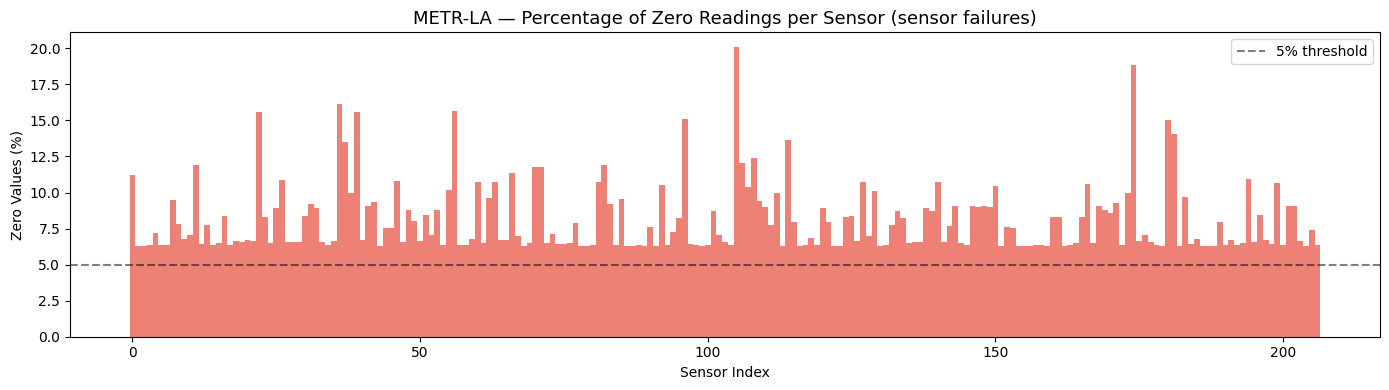

In [7]:
# Zero values analysis (sensor failures)
zero_pct_la = (df_la == 0).mean() * 100
print(f"METR-LA sensors with >5% zeros: {(zero_pct_la > 5).sum()} / {len(zero_pct_la)}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(zero_pct_la)), zero_pct_la.values, color='#e74c3c', alpha=0.7, width=1.0)
ax.set_xlabel('Sensor Index')
ax.set_ylabel('Zero Values (%)')
ax.set_title('METR-LA — Percentage of Zero Readings per Sensor (sensor failures)', fontsize=13)
ax.axhline(5, color='black', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/plots/zero_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing — Missing Values & Normalization

In [8]:
from src.data_loader import handle_missing_values, normalize_data, load_csv

# Load and clean METR-LA
raw_data, sensor_ids, timestamps = load_csv(config.METR_LA_PATH)
print(f"\nBefore cleaning: zeros={int((raw_data == 0).sum())}, NaN={int(np.isnan(raw_data).sum())}")

cleaned_data = handle_missing_values(raw_data)
print(f"After cleaning:  zeros={int((cleaned_data == 0).sum())}, NaN={int(np.isnan(cleaned_data).sum())}")
print(f"Speed range: [{cleaned_data.min():.2f}, {cleaned_data.max():.2f}] mph")

Loading /home/anonymous/GraphNN/dataset/METR-LA.csv...
  Shape: (34272, 207) (timesteps × sensors)
  Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
  Missing values: 0 (0.00%)
  Zero values: 575302 (8.11%)

Before cleaning: zeros=575302, NaN=0
  After cleaning — NaN: 0, Zeros: 0
After cleaning:  zeros=0, NaN=0
Speed range: [0.33, 70.00] mph


Normalization stats computed from training data (23990 timesteps)
Per-sensor mean range: [30.88, 67.76]
Per-sensor std range:  [1.94, 22.93]
Normalized data range: [-32.45, 7.13]


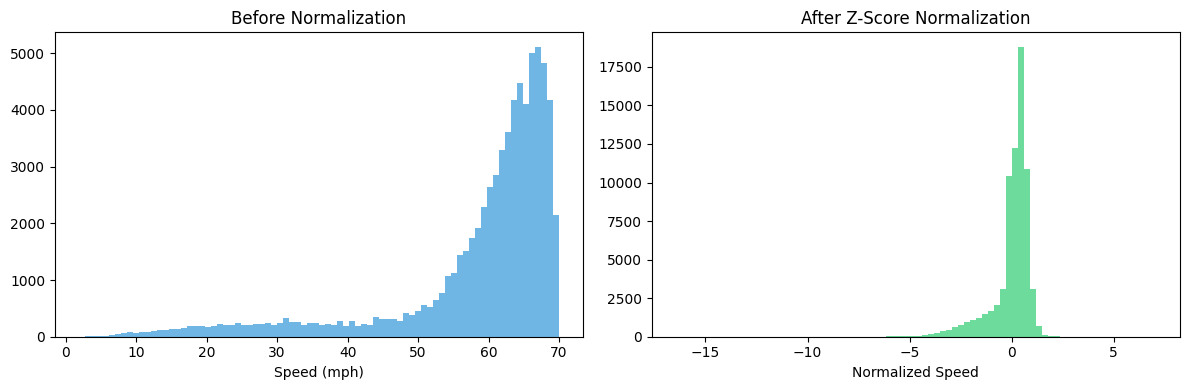

In [9]:
# Z-score normalization (using training data stats only)
train_end = int(len(cleaned_data) * config.TRAIN_RATIO)
train_data = cleaned_data[:train_end]

mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
std[std < 1e-5] = 1.0  # Avoid div-by-zero

normalized = (cleaned_data - mean) / std

print(f"Normalization stats computed from training data ({train_end} timesteps)")
print(f"Per-sensor mean range: [{mean.min():.2f}, {mean.max():.2f}]")
print(f"Per-sensor std range:  [{std.min():.2f}, {std.max():.2f}]")
print(f"Normalized data range: [{normalized.min():.2f}, {normalized.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cleaned_data.flatten()[::100], bins=80, color='#3498db', alpha=0.7)
axes[0].set_title('Before Normalization', fontsize=12)
axes[0].set_xlabel('Speed (mph)')

axes[1].hist(normalized.flatten()[::100], bins=80, color='#2ecc71', alpha=0.7)
axes[1].set_title('After Z-Score Normalization', fontsize=12)
axes[1].set_xlabel('Normalized Speed')

plt.tight_layout()
plt.savefig('../results/plots/normalization.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sliding Window Sequences

In [10]:
from src.data_loader import create_sequences, split_data

SEQ_LEN = config.SEQ_LEN    # 12 steps = 1 hour input
PRED_LEN = config.PRED_LEN  # 12 steps = 1 hour prediction

print(f"Input window:  {SEQ_LEN} steps = {SEQ_LEN * 5} minutes")
print(f"Prediction:    {PRED_LEN} steps = {PRED_LEN * 5} minutes")

X, Y = create_sequences(normalized, SEQ_LEN, PRED_LEN)

print(f"\nX shape: {X.shape} — (samples, seq_len, sensors)")
print(f"Y shape: {Y.shape} — (samples, pred_len, sensors)")

Input window:  12 steps = 60 minutes
Prediction:    12 steps = 60 minutes
  Created 34249 sequences: X=(34249, 12, 207), Y=(34249, 12, 207)

X shape: (34249, 12, 207) — (samples, seq_len, sensors)
Y shape: (34249, 12, 207) — (samples, pred_len, sensors)


  train: 23974 samples
  val: 3425 samples
  test: 6850 samples

Split ratios: Train=0.7, Val=0.1, Test=0.2
  train: 23974 samples (70.0%)
  val: 3425 samples (10.0%)
  test: 6850 samples (20.0%)


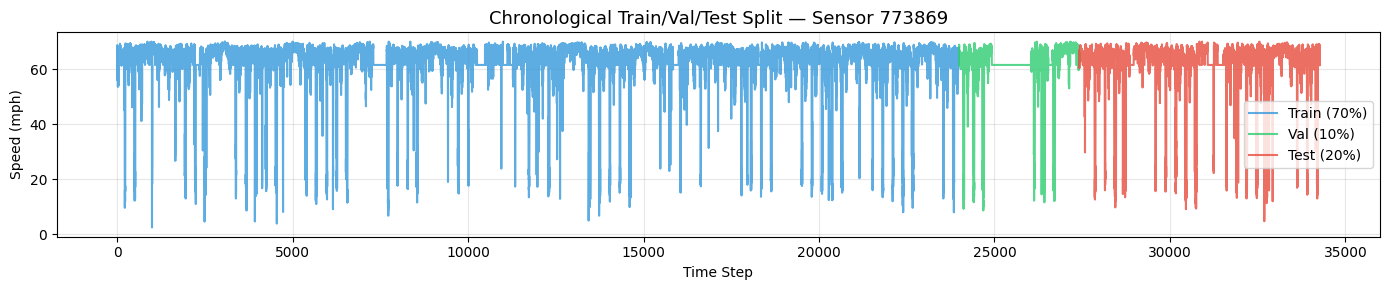

In [11]:
# Chronological split
splits = split_data(X, Y, config.TRAIN_RATIO, config.VAL_RATIO)

print(f"\nSplit ratios: Train={config.TRAIN_RATIO}, Val={config.VAL_RATIO}, Test={config.TEST_RATIO}")
for name, (x, y) in splits.items():
    pct = len(x) / len(X) * 100
    print(f"  {name}: {len(x)} samples ({pct:.1f}%)")

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 3))
sensor_idx = 0
full_series = cleaned_data[:, sensor_idx]
n = len(full_series)
t_train = int(n * config.TRAIN_RATIO)
t_val = int(n * (config.TRAIN_RATIO + config.VAL_RATIO))

ax.plot(range(0, t_train), full_series[:t_train], color='#3498db', label='Train (70%)', alpha=0.8)
ax.plot(range(t_train, t_val), full_series[t_train:t_val], color='#2ecc71', label='Val (10%)', alpha=0.8)
ax.plot(range(t_val, n), full_series[t_val:], color='#e74c3c', label='Test (20%)', alpha=0.8)
ax.set_title(f'Chronological Train/Val/Test Split — Sensor {sensor_ids[0]}', fontsize=13)
ax.set_xlabel('Time Step')
ax.set_ylabel('Speed (mph)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/data_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Graph Construction

In [14]:
from src.graph_builder import compute_correlation_adj, symmetric_normalize, build_graph

# Build graph from training data only
graph_data = build_graph(
    train_data,
    sigma=config.GRAPH_SIGMA,
    epsilon=config.GRAPH_EPSILON,
    K_cheb=config.STGCN_K,
    K_diff=config.DIFFUSION_STEPS,
)

adj = graph_data['adj']
print(f"Adjacency matrix: {adj.shape}")
print(f"Edge weights range: [{adj[adj > 0].min():.4f}, {adj.max():.4f}]")
print(f"Avg degree: {(adj > 0).sum(axis=1).mean():.1f}")

Building graph from sensor correlations...
  Adjacency matrix: 207x207
  Non-zero entries: 447 / 42849
  Sparsity: 98.96%
  Avg connections per node: 2.2
  Computing Chebyshev polynomials...
  Computing diffusion matrices...
Graph construction complete.

Adjacency matrix: (207, 207)
Edge weights range: [0.3112, 1.0000]
Avg degree: 2.2


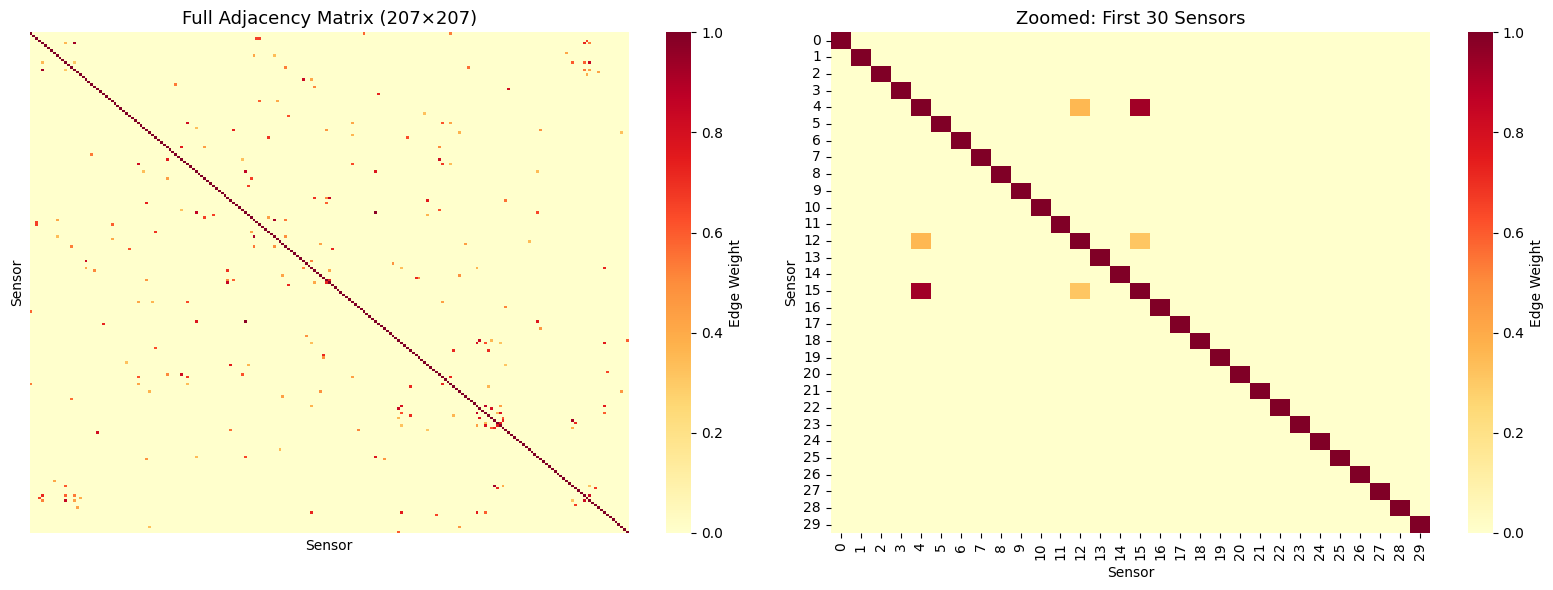

In [15]:
# Visualize adjacency matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
sns.heatmap(adj, cmap='YlOrRd', ax=axes[0], xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Edge Weight'})
axes[0].set_title('Full Adjacency Matrix (207×207)', fontsize=13)
axes[0].set_xlabel('Sensor')
axes[0].set_ylabel('Sensor')

# Zoomed top-left 30x30
sns.heatmap(adj[:30, :30], cmap='YlOrRd', ax=axes[1], annot=False,
            cbar_kws={'label': 'Edge Weight'})
axes[1].set_title('Zoomed: First 30 Sensors', fontsize=13)
axes[1].set_xlabel('Sensor')
axes[1].set_ylabel('Sensor')

plt.tight_layout()
plt.savefig('../results/plots/adjacency_matrix_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

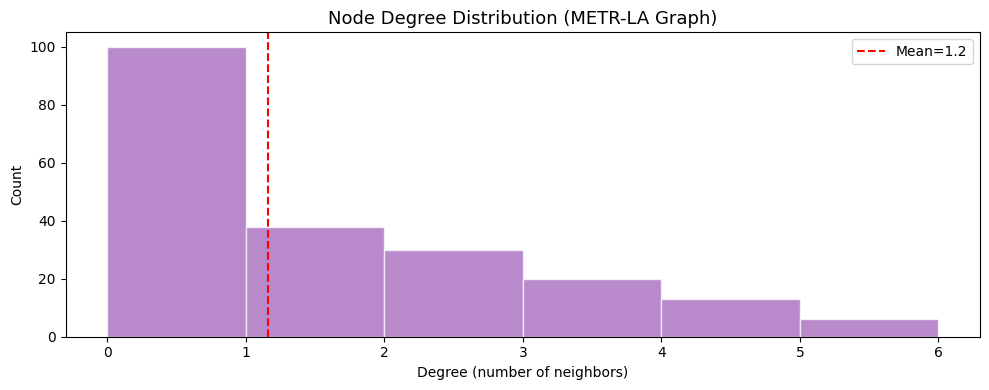

In [16]:
# Degree distribution
degrees = (adj > 0).sum(axis=1) - 1  # exclude self-loops
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(degrees, bins=range(0, int(degrees.max()) + 2), color='#9b59b6',
        alpha=0.7, edgecolor='white')
ax.set_title('Node Degree Distribution (METR-LA Graph)', fontsize=13)
ax.set_xlabel('Degree (number of neighbors)')
ax.set_ylabel('Count')
ax.axvline(degrees.mean(), color='red', linestyle='--', label=f'Mean={degrees.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('../results/plots/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

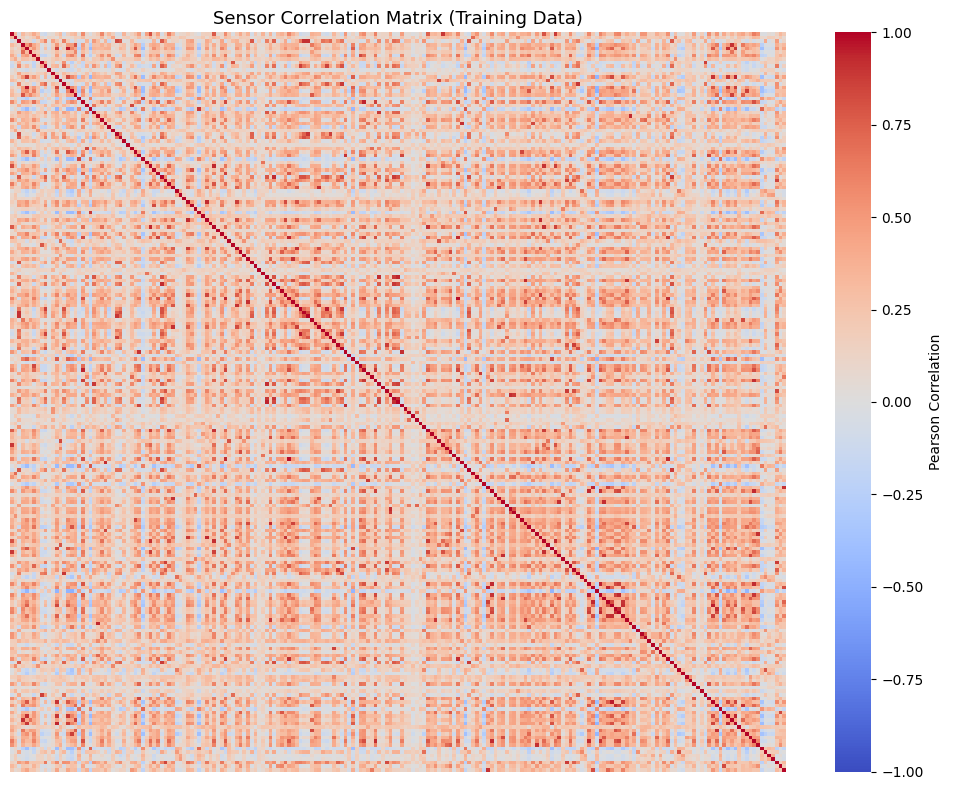

In [17]:
# Sensor correlation matrix
corr = np.corrcoef(train_data.T)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, xticklabels=False, yticklabels=False,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Sensor Correlation Matrix (Training Data)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/plots/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Training
Run training from here. Each model can be trained independently.

**Note:** ARIMA takes ~10 min, RF ~1 min, LSTM ~5 min, STGCN ~5 min, DCRNN ~10 min

In [ ]:
from src.data_loader import prepare_dataset
from src.train import train_model, predict_model
from src.evaluate import evaluate_predictions, print_results, compare_models

# Full data preparation pipeline
data = prepare_dataset(
    config.METR_LA_PATH,
    seq_len=config.SEQ_LEN,
    pred_len=config.PRED_LEN,
    batch_size=config.BATCH_SIZE,
)

mean_norm = data['mean']
std_norm = data['std']
num_sensors = data['splits']['train'][0].shape[2]

# Rebuild graph
train_end_idx = int(len(data['raw_data']) * config.TRAIN_RATIO)
graph = build_graph(data['raw_data'][:train_end_idx],
                    sigma=config.GRAPH_SIGMA, epsilon=config.GRAPH_EPSILON)

all_results = {}
all_preds = {}
histories = {}
test_Y = data['splits']['test'][1]

### 7a. ARIMA (Statistical Baseline)

In [ ]:
from src.models.arima_model import ARIMAForecaster

train_X_np = data['splits']['train'][0]
T_train = len(train_X_np) + config.SEQ_LEN - 1
train_series = np.zeros((T_train, num_sensors))
train_series[:config.SEQ_LEN] = train_X_np[0]
for i in range(1, len(train_X_np)):
    train_series[config.SEQ_LEN + i - 1] = train_X_np[i, -1]

arima = ARIMAForecaster(order=config.ARIMA_ORDER, max_sensors=config.ARIMA_MAX_SENSORS)
preds = arima.fit_and_predict(train_series, data['splits']['test'][0], config.PRED_LEN)

r = evaluate_predictions(preds, test_Y, mean_norm, std_norm)
print_results(r, arima.get_name())
all_results['ARIMA'] = r
all_preds['ARIMA'] = preds

### 7b. Random Forest (ML Baseline)

In [ ]:
from src.models.rf_model import RandomForestForecaster

rf = RandomForestForecaster(n_estimators=config.RF_N_ESTIMATORS,
                            max_depth=config.RF_MAX_DEPTH, n_jobs=config.RF_N_JOBS)
rf.fit(data['splits']['train'][0], data['splits']['train'][1])
preds = rf.predict(data['splits']['test'][0])

r = evaluate_predictions(preds, test_Y, mean_norm, std_norm)
print_results(r, rf.get_name())
all_results['RandomForest'] = r
all_preds['RandomForest'] = preds

### 7c. LSTM (Deep Learning Baseline)

In [ ]:
from src.models.lstm_model import LSTMModel

lstm = LSTMModel(num_sensors, config.SEQ_LEN, config.PRED_LEN,
                 config.LSTM_HIDDEN, config.LSTM_LAYERS, config.LSTM_DROPOUT)
print(f"LSTM parameters: {sum(p.numel() for p in lstm.parameters()):,}")

history = train_model(lstm, data['loaders']['train'], data['loaders']['val'],
                      config, 'lstm', 'METR-LA')
preds, gt = predict_model(lstm, data['loaders']['test'], config, 'lstm')

r = evaluate_predictions(preds, gt, mean_norm, std_norm)
print_results(r, lstm.get_name())
all_results['LSTM'] = r
all_preds['LSTM'] = preds
histories['LSTM'] = history

### 7d. STGCN (Graph Conv + Temporal Conv)

In [ ]:
from src.models.stgcn import STGCN

stgcn = STGCN(num_sensors, config.SEQ_LEN, config.PRED_LEN,
              K=config.STGCN_K, channels=config.STGCN_CHANNELS)
print(f"STGCN parameters: {sum(p.numel() for p in stgcn.parameters()):,}")

history = train_model(stgcn, data['loaders']['train'], data['loaders']['val'],
                      config, 'stgcn', 'METR-LA', graph_data=graph)
preds, gt = predict_model(stgcn, data['loaders']['test'], config, 'stgcn', graph_data=graph)

r = evaluate_predictions(preds, gt, mean_norm, std_norm)
print_results(r, stgcn.get_name())
all_results['STGCN'] = r
all_preds['STGCN'] = preds
histories['STGCN'] = history

### 7e. DCRNN (Diffusion Conv + GRU)

In [ ]:
from src.models.dcrnn import DCRNN

n_supports = len(graph['diffusion_supports'])
dcrnn = DCRNN(num_sensors, n_supports, config.SEQ_LEN, config.PRED_LEN,
              config.DCRNN_HIDDEN, config.DCRNN_LAYERS)
print(f"DCRNN parameters: {sum(p.numel() for p in dcrnn.parameters()):,}")

history = train_model(dcrnn, data['loaders']['train'], data['loaders']['val'],
                      config, 'dcrnn', 'METR-LA', graph_data=graph)
preds, gt = predict_model(dcrnn, data['loaders']['test'], config, 'dcrnn', graph_data=graph)

r = evaluate_predictions(preds, gt, mean_norm, std_norm)
print_results(r, dcrnn.get_name())
all_results['DCRNN'] = r
all_preds['DCRNN'] = preds
histories['DCRNN'] = history

## 8. Results Comparison

In [ ]:
compare_models(all_results, 'METR-LA')

In [ ]:
# Results as DataFrame for paper
rows = []
for model_name, r in all_results.items():
    for horizon in ['15min', '30min', '60min']:
        if horizon in r:
            rows.append({
                'Model': model_name,
                'Horizon': horizon,
                'MAE': r[horizon]['MAE'],
                'RMSE': r[horizon]['RMSE'],
                'MAPE (%)': r[horizon]['MAPE'],
            })

results_df = pd.DataFrame(rows)
print("\n=== Results Table (copy to paper) ===\n")
print(results_df.to_string(index=False, float_format='%.4f'))

# Save as CSV
results_df.to_csv('../results/metrics/METR-LA_results_table.csv', index=False)
print("\nSaved to results/metrics/METR-LA_results_table.csv")

## 9. Visualization

In [ ]:
from src.visualize import (plot_predictions, plot_model_comparison,
                            plot_horizon_performance, plot_training_curves,
                            plot_spatial_error)

save_dir = '../results/plots'

# Model comparison bar chart
plot_model_comparison(all_results, 'METR-LA',
                      save_path=f'{save_dir}/METR-LA_comparison.png')

# Horizon performance
plot_horizon_performance(all_results, 'METR-LA',
                         save_path=f'{save_dir}/METR-LA_horizons.png')

# Training curves
if histories:
    plot_training_curves(histories, 'METR-LA',
                         save_path=f'{save_dir}/METR-LA_training.png')

print("All comparison plots saved!")

In [ ]:
# Prediction vs Ground Truth for specific sensors
for sensor in [0, 50, 100]:
    if sensor < num_sensors:
        plot_predictions(all_preds, test_Y, mean_norm, std_norm,
                         sensor_idx=sensor, time_range=(0, 288),
                         save_path=f'{save_dir}/METR-LA_pred_sensor{sensor}.png')

print("Prediction plots saved!")

In [ ]:
# Spatial error analysis — which sensors are hardest to predict?
for model_name in ['STGCN', 'DCRNN']:
    if model_name in all_preds:
        plot_spatial_error(all_preds[model_name], test_Y, mean_norm, std_norm,
                           'METR-LA', model_name,
                           save_path=f'{save_dir}/METR-LA_{model_name}_spatial.png')

## 10. Key Findings Summary

After running all cells above, summarize:

| Question | Answer |
|----------|--------|
| Does graph structure help? | Compare STGCN/DCRNN vs LSTM MAE |
| Which GNN is better? | Compare STGCN vs DCRNN |
| How does error grow with horizon? | Check 15min vs 60min MAE |
| Which sensors are hardest? | Check spatial error plots |
| Are results consistent? | Run on PEMS-BAY and compare |

In [ ]:
# Final summary
print("\n" + "="*60)
print("  FINAL SUMMARY — METR-LA")
print("="*60)
for name, r in sorted(all_results.items(), key=lambda x: x[1]['overall']['MAE']):
    mae = r['overall']['MAE']
    rmse = r['overall']['RMSE']
    mape = r['overall']['MAPE']
    print(f"  {name:<20} MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%")

if 'LSTM' in all_results and 'STGCN' in all_results:
    imp = (all_results['LSTM']['overall']['MAE'] - all_results['STGCN']['overall']['MAE'])
    imp_pct = imp / all_results['LSTM']['overall']['MAE'] * 100
    print(f"\n  → STGCN improvement over LSTM: {imp_pct:.1f}%")

if 'LSTM' in all_results and 'DCRNN' in all_results:
    imp = (all_results['LSTM']['overall']['MAE'] - all_results['DCRNN']['overall']['MAE'])
    imp_pct = imp / all_results['LSTM']['overall']['MAE'] * 100
    print(f"  → DCRNN improvement over LSTM: {imp_pct:.1f}%")

print("\nDone! All results and plots saved to results/")